In [21]:
from ngsolve import *
from ngsolve.webgui import Draw
from netgen.occ import *
from netgen.geom2d import SplineGeometry
"""
der Code macht:
1. simuliert die Kirchhoff-love Gl mit HHJ-methode (gravitation)
2. nimmt eine 'verworfene' Platte (startwert), werte kommen auf einer funktion 'f'
3. rechnete diese linear (addition) zusammen
4. speichert diese außerdem als *.xyz datei ab 
5. plottet diese *.xyz-Files mit matplotlib und gibt die Max-Änderung durch die Gravitation aus

FILE hat hier noch Probleme, beim *.xyz-File erstellen, wegen 'out of domain', bei den ausgeschnittenen Kreisen

"""


#EINHEITEN in MILLIMETER, KILOGRAMM, SEKUNDEN
l = 1100    #mm Länge
b = 360     #mm Breite
t  = 4      #mm Dicke 


radius = 25 #mm Radius der Kreise für Auflager

#region GEOMETRIE
shape = MoveTo(0,0).Rectangle(l,b).Face()

shape.edges.name="free"

#circle = Circle((0,0),0.10).Face()
#circle.edges.name="circles"

rect = shape 

#KREISAUFLAGER
auflager_liste = [(radius,radius),(l-radius,b-radius),(radius,b-radius),(l-radius,radius),(l/2,b/2)]

for mittelpunkt in auflager_liste:
    circle = Circle(mittelpunkt,radius).Face()
    circle.edges.name = "dirichlet"
    rect = rect - circle

#KANTENAUFLAGER
# rect.edges.Min(X).name = "dirichlet"
# rect.edges.Max(X).name = "dirichlet"

geo = OCCGeometry(rect,dim=2)

#Draw(rect)
mesh = Mesh(geo.GenerateMesh(maxh=l/40))

mesh.Curve(3)
#Draw(mesh)

#endregion

In [22]:
E  = 70e6               #N/mm² ~ 70 GPa Elastizitätsmodul Glas
nu = 0.23               #Poisson-Zahl (dimensionslos)
rho = 2.5*10**(-6)      #kg/mm^3 Dichte einer Aluminiumplatte
g = 9810                #mm/s²

q = rho * t * g         #Eigengewicht der Platte punktweise!!! - rechte Seite der PDE, also unser f_PDE

#region FUNKTIONEN für PDE
Db = E*t**3/(12*(1-nu**2))

def D(A):
    return Db *((1-nu)*A+ nu*Trace(A)*Id(2))

def Dinv(A):
    return 1/Db * (1/(1-nu)*A - nu/(1-nu**2)*Trace(A)*Id(2))
#endregion

In [23]:
#region SIMULATION: FUNKTIONENRAUM,SCHWACHE FORM,VISUALISIERUNG
order = 3

V = HDivDiv(mesh, order=order-1,dirichlet="dirichlet")
Q = H1(mesh, order=order, dirichlet="dirichlet")
X = V * Q

(sigma,w),(tau,v)= X.TnT()

n = specialcf.normal(2)

def tang(u):
    return u - (u*n)*n


#schwache Form von Kirchhoff-Love mit Hellan-Herrmann-Johnson-Method
#https://docu.ngsolve.org/ngs24/SaS/Kirchhoff_Love_plate.html

a = BilinearForm(X,symmetric=True)
a += InnerProduct(Dinv(sigma),tau) * dx
a += div(sigma)*Grad(v) * dx
a += div(tau) * Grad(w) * dx
a += - (sigma[n,:] * tang(Grad(v)) + tau[n,:] * tang(Grad(w))  ) * dx(element_boundary=True)
a.Assemble()

L = LinearForm(X)
L += q * v *dx
L.Assemble()

gf_solution = GridFunction(X)
gf_solution.vec.data = a.mat.Inverse(X.FreeDofs(),inverse="") * L.vec

gf_sigma, gf_w = gf_solution.components
#Draw(gf_sigma, mesh,name="sigma")
Draw(gf_w, mesh, name="disp",deformation=True, euler_angles=[-60,5,30])

#endregion

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {'camera': {'euler_angles': […

BaseWebGuiScene

In [24]:
#zum Weiterrechnen, wollen wir auf die errechneten Daten zugreifen können
import numpy as np
import inspect

#Werte für FUNKTION - benötigt für Ausgangsglasplatte
c = 12    #höhe in der mitte
a = c/((l/2)**2)

def f(x,y): # c - a * (x-l/2)²  
    """diese Funktion bestimmt die Verwerfung der gemessenen Glasplatte, Achtung nicht zu verwechseln mit der rechten Seite 'f', aus der Thematik der PDEs, (bei uns die Eigenlast 'q')"""
  
    return (c - a * (x-l/2)**2) * 0.01

#region WERTE-MATRIZEN BILDEN

step = 40           #TODO warum ab 41 out of domain?

#erzeugt gitter für gewünschte werte
x_points = np.linspace(0,l, step)
y_points = np.linspace(0,b, step)
X, Y = np.meshgrid(x_points, y_points)

#speichert (x,y,z) in gravitation_matrix für alle (x,y) in X,Y
gravitation_matrix = np.zeros((step, step),dtype=object)
for i in range(step):
    for j in range(step):
        try:
            z_eintrag = gf_w(X[i, j], Y[i, j])
        except:
            z_eintrag = 0
        gravitation_matrix[i, j] = (float(X[i,j]), float(Y[i,j]), z_eintrag )


#print(gravitation_matrix)

#speichert (x,y,z) in startwerte_matrix für alle (x,y) in X,Y
startwerte_matrix = np.zeros((step, step),dtype=object)
for i in range(step):
    for j in range(step):
        startwerte_matrix[i, j] = (float(X[i,j]), float(Y[i,j]), float(f(X[i, j], Y[i, j])) )       #hier: Funktion 'f' statt 'gf_w'

#print(startwerte_matrix)

#RUECKRECHNEN
#speichert (x,y,z) in gravitation_matrix für alle (x,y) in X,Y
endwerte_matrix = np.zeros((step, step),dtype=object)
for i in range(step):
    for j in range(step):
        endwerte_matrix[i, j] = (float(X[i,j]), float(Y[i,j]), float(f(X[i, j], Y[i, j])) - float(gravitation_matrix[i,j][2])  )       #hier: Funktion 'gf_w' + 'f'
        #endwerte_matrix[i, j] = (float(X[i, j]), float(Y[i, j]), f(X[i, j], Y[i, j]) )          


#print(endwerte_matrix)

#endregion

#region MATRIZEN SPEICHERN als *.xyz FILES

#speichert die Werte in *.xyz-Datei
# GRAVITATION-Matrix
filename_gravitation = f"{t}mm_gravitation.xyz"
with open(filename_gravitation, "w") as f:
    for i in range(step):
        for j in range(step):
            x, y, w = gravitation_matrix[i, j]
            f.write(f"{x:.6f}\t{y:.6f}\t{w:.6e}\n")

# STARTWERTE-Matrix     - red
filename_startwerte = f"{t}mm_startwerte.xyz"
with open(filename_startwerte, "w") as f:
    for i in range(step):
        for j in range(step):
            x, y, w = startwerte_matrix[i, j]
            f.write(f"{x:.6f}\t{y:.6f}\t{w:.6e}\n")


#speichert die Werte in *.xyz-Datei
# ENTWERTE-Matrix       - green
filename_endwerte = f"{t}mm_endwerte.xyz"
with open(filename_endwerte, "w") as f:
    for i in range(step):
        for j in range(step):
            x, y, w = endwerte_matrix[i, j]
            f.write(f"{x:.6f}\t{y:.6f}\t{w:.6e}\n")

#endregion

Dicke=4m,a=3.9669421487603306e-05,c=12,l=1100m,b=360 und f(x) =  12 - 3.9669421487603306e-05*(x-1100/2)**2
Höchster Wert:
 startwert:   0.1199211
 gravitation: -0.03055377
 endwert:     0.1504749
SOLLWERT 0.015
 endwert - startwert:     0.030553799999999992
 prozentuelle Änderung:     125.48 %


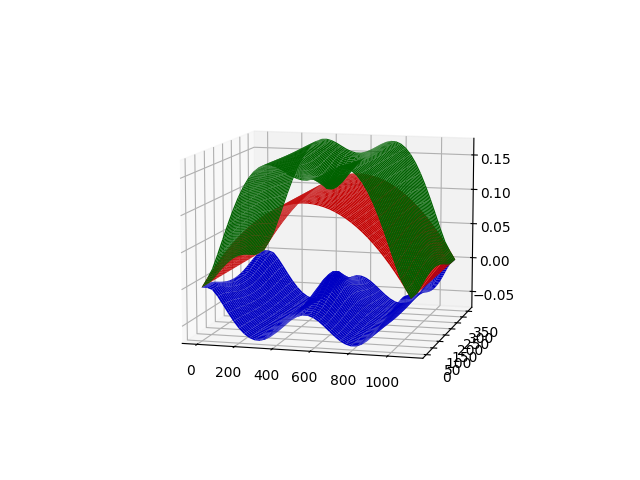

In [25]:
#region PLOTTEN

%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(threshold=np.inf)
data1 = np.loadtxt(filename_startwerte)
data2 = np.loadtxt(filename_gravitation)
data3 = np.loadtxt(filename_endwerte)

x1= data1[:,0]
y1= data1[:,1]
z1= data1[:,2]

x2= data2[:,0]
y2= data2[:,1]
z2= data2[:,2]

x3= data3[:,0]
y3= data3[:,1]
z3= data3[:,2]

# Raster erzeugen
X = np.unique(x1)
Y = np.unique(y1)

X, Y = np.meshgrid(X, Y)
Z1=z1.reshape(len(Y), len(X))
Z2=z2.reshape(len(Y), len(X))
Z3=z3.reshape(len(Y), len(X))


fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.plot_surface(X, Y,Z1,color="red")        # startwerte
ax.plot_surface(X, Y,Z2,color="blue")       # gravitation
ax.plot_surface(X, Y,Z3,color="green")      # endwerte


ax.view_init(elev=10, azim=-75)
#plt.show()

#endregion

print(f"Dicke={t}m,a={a},c={c},l={l}m,b={b} und f(x) =  {c} - {a}*(x-{l}/2)**2")
print('Höchster Wert:')
print(' startwert:  ', z1[20])
print(' gravitation:', z2[20])
print(' endwert:    ', z3[20])
print("SOLLWERT 0.015")
print(' endwert - startwert:    ',z3[20] - z1[20])
print(' prozentuelle Änderung:    ', round(((100/z1[20]) * z3[20]),2),'%')
